<a href="https://colab.research.google.com/github/JPAmewu/My_Capstone_1_Imperial/blob/main/Week_5_Capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import os
import shutil
import zipfile
import numpy as np
import pandas as pd

# remove old folders if they exist
shutil.rmtree("/content/week_4_data", ignore_errors=True)
shutil.rmtree("/content/week_5_data", ignore_errors=True)

# unzip week 4 data
with zipfile.ZipFile("/content/week_4_data.zip", "r") as zip_ref:
    zip_ref.extractall("/content/week_4_data")

print("Week 4 data unzipped successfully")

Week 4 data unzipped successfully


In [2]:
# Load week 4 accumulated. npy files

week_5_data = {}

for fn in range(1, 9):
    X_path = f"/content/week_4_data/week_4_data/function_{fn}_inputs.npy"
    y_path = f"/content/week_4_data/week_4_data/function_{fn}_outputs.npy"

    X = np.load(X_path)
    y = np.load(y_path)

    week_5_data[fn] = {"X": X, "y": y}

    print(f"Function {fn}: X shape {X.shape}, y shape {y.shape}")

Function 1: X shape (13, 2), y shape (13,)
Function 2: X shape (13, 2), y shape (13,)
Function 3: X shape (18, 3), y shape (18,)
Function 4: X shape (33, 4), y shape (33,)
Function 5: X shape (23, 4), y shape (23,)
Function 6: X shape (23, 5), y shape (23,)
Function 7: X shape (33, 6), y shape (33,)
Function 8: X shape (43, 8), y shape (43,)


In [3]:
# Load week 4 inputs and outputs

week_4_inputs_raw = pd.read_csv("/content/Week_4_inputs.txt", header=None).values.flatten()
week_4_outputs_raw = pd.read_csv("/content/Week_4_outputs.txt", header=None).values.flatten()

print("Week 4 inputs length:", len(week_4_inputs_raw))
print("Week 4 outputs length:", len(week_4_outputs_raw))

Week 4 inputs length: 264
Week 4 outputs length: 32


In [4]:
# Append week results to create week 5 dataset

dims = {
    1: 2,
    2: 2,
    3: 3,
    4: 4,
    5: 4,
    6: 5,
    7: 6,
    8: 8
}

start = 0

for fn in range(1, 9):
    dim = dims[fn]

    X_old = week_5_data[fn]["X"]
    y_old = week_5_data[fn]["y"]

    new_x = week_4_inputs_raw[start:start + dim].reshape(1, dim)
    new_y = week_4_outputs_raw[fn - 1]

    start += dim

    X_new = np.vstack([X_old, new_x])
    y_new = np.append(y_old, new_y)

    week_5_data[fn] = {"X": X_new, "y": y_new}

    print(f"Function {fn}: X shape {X_new.shape}, y shape {y_new.shape}")

Function 1: X shape (14, 2), y shape (14,)
Function 2: X shape (14, 2), y shape (14,)
Function 3: X shape (19, 3), y shape (19,)
Function 4: X shape (34, 4), y shape (34,)
Function 5: X shape (24, 4), y shape (24,)
Function 6: X shape (24, 5), y shape (24,)
Function 7: X shape (34, 6), y shape (34,)
Function 8: X shape (44, 8), y shape (44,)


In [5]:
# Save week 5 dataset

os.makedirs("/content/week_5_data", exist_ok=True)

for fn in range(1, 9):
    np.save(f"/content/week_5_data/function_{fn}_inputs.npy", week_5_data[fn]["X"])
    np.save(f"/content/week_5_data/function_{fn}_outputs.npy", week_5_data[fn]["y"])

print("Week 5 dataset created and saved successfully")

Week 5 dataset created and saved successfully



Function 1
Shape X: (14, 2)
Shape y: (14,)
Best y: [np.float64(-1.560646704467778e-117)
Best x: ['[array([0.37454 ' ' 0.950714])']


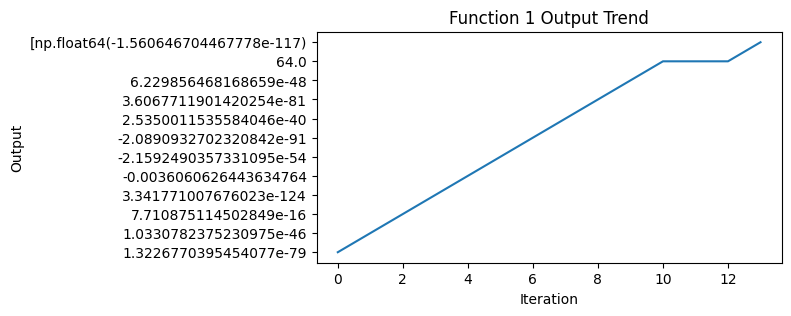


Function 2
Shape X: (14, 2)
Shape y: (14,)
Best y: 0.6112052157614438
Best x: [0.7026365569244406 0.9265641975455574]


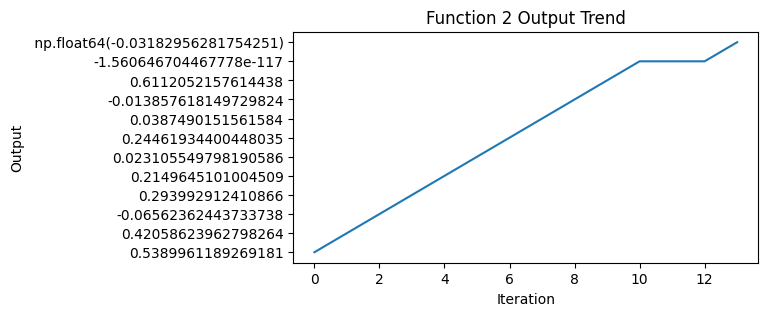


Function 3
Shape X: (19, 3)
Shape y: (19,)
Best y: 64.0
Best x: [0.444444 0.666666 0.333333]


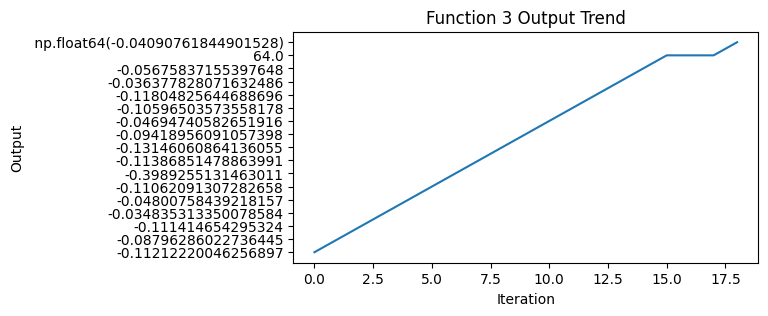


Function 4
Shape X: (34, 4)
Shape y: (34,)
Best y: -7.9667753510303925
Best x: [0.28213836819277516 0.5059869120612994 0.5305308425014074
 0.09630162301775336]


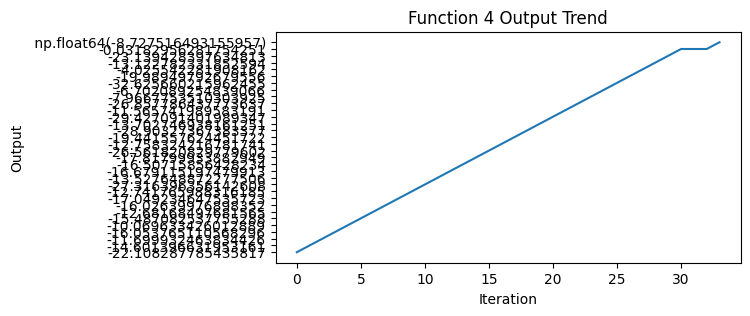


Function 5
Shape X: (24, 4)
Shape y: (24,)
Best y: 9.972331894593824
Best x: [0.12688467007850324 0.15342962125134962 0.770162187580243
 0.19051810509577394]


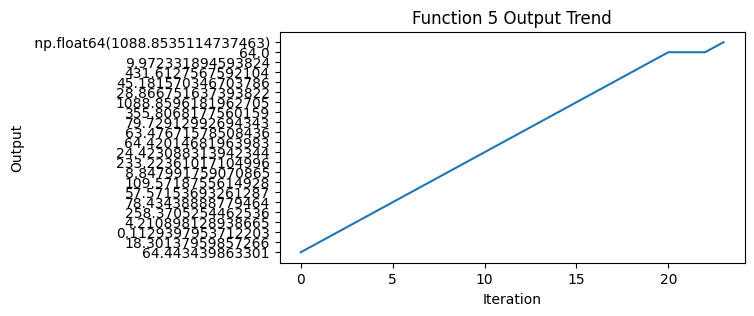


Function 6
Shape X: (24, 5)
Shape y: (24,)
Best y: -2.5711696316081234
Best x: [0.12572015503019873 0.8627246921598651 0.028544332231059788
 0.24660527193052817 0.7512062409044311]


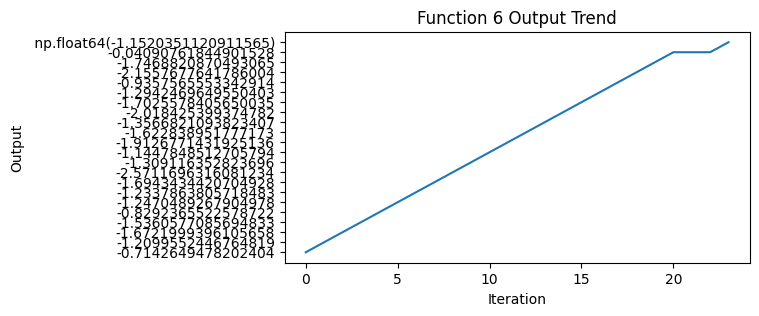


Function 7
Shape X: (34, 6)
Shape y: (34,)
Best y: 64.0
Best x: [0.045091 0.528666 0.329265 0.10535 0.434667 0.641164]


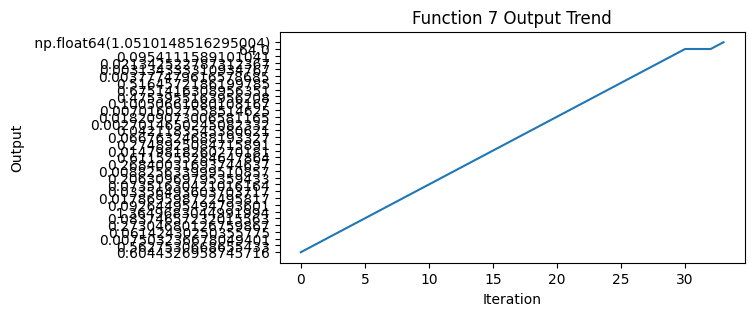


Function 8
Shape X: (44, 8)
Shape y: (44,)
Best y: 9.598482002566342
Best x: [0.056447411065611686 0.06595555344270987 0.02292867798954412
 0.038786472359111146 0.4039354405187773 0.8010553292222439
 0.48830700691299356 0.8930849765397529]


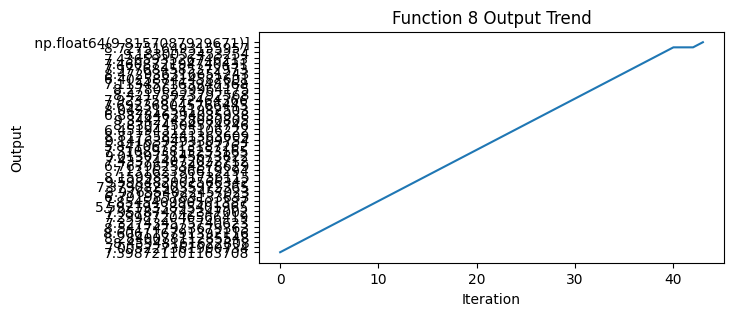

In [6]:
import numpy as np
import matplotlib.pyplot as plt

best_points = {}

for fn in range(1,9):
    X = np.load(f"/content/week_5_data/function_{fn}_inputs.npy", allow_pickle=True)
    y = np.load(f"/content/week_5_data/function_{fn}_outputs.npy", allow_pickle=True)

    best_idx = np.argmax(y)

    best_points[fn] = {
        "best_x": X[best_idx],
        "best_y": y[best_idx]
    }

    print(f"\nFunction {fn}")
    print("Shape X:", X.shape)
    print("Shape y:", y.shape)
    print("Best y:", y[best_idx])
    print("Best x:", X[best_idx])

    plt.figure(figsize=(6,3))
    plt.plot(y)
    plt.title(f"Function {fn} Output Trend")
    plt.xlabel("Iteration")
    plt.ylabel("Output")
    plt.show()

In [7]:
import numpy as np
import pandas as pd
import re

def load_week4_txt(path):
    text = open(path).read()
    nums = re.findall(r"[-+]?\d*\.\d+|\d+", text)
    return np.array(nums, dtype=float)

week4_inputs = load_week4_txt("/content/Week_4_inputs.txt")
week4_outputs = load_week4_txt("/content/Week_4_outputs.txt")

print("Week 4 inputs length:", len(week4_inputs))
print("Week 4 outputs length:", len(week4_outputs))

Week 4 inputs length: 143
Week 4 outputs length: 68


In [13]:
import numpy as np
import pandas as pd
import zipfile
import re
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern
from scipy.stats import norm

# ==============================
# STEP 1: Unzip Week 4 data
# ==============================
with zipfile.ZipFile("/content/week_4_data.zip", "r") as zip_ref:
    zip_ref.extractall("/content/week_4_data")

# ==============================
# STEP 2: Clean txt files
# ==============================
def load_week4_txt(path):
    text = open(path).read()
    nums = re.findall(r"[-+]?\d*\.\d+|\d+", text)
    return np.array(nums, dtype=float)

week4_inputs = load_week4_txt("/content/Week_4_inputs.txt")
week4_outputs = load_week4_txt("/content/Week_4_outputs.txt")

print("Week 4 inputs loaded:", len(week4_inputs))
print("Week 4 outputs loaded:", len(week4_outputs))

# ==============================
# STEP 3: Function dimensions
# ==============================
dims = {
    1:2,
    2:2,
    3:3,
    4:4,
    5:4,
    6:5,
    7:6,
    8:8
}

# ==============================
# STEP 4: Week 5 Strategy
# ==============================
strategies = {
    1: {"kernel": RBF(), "acq": "UCB", "kappa": 5},
    2: {"kernel": Matern(), "acq": "UCB", "kappa": 5},
    3: {"kernel": Matern(), "acq": "UCB", "kappa": 4},
    4: {"kernel": Matern(), "acq": "UCB", "kappa": 4},
    5: {"kernel": RBF(), "acq": "EI"},
    6: {"kernel": Matern(), "acq": "UCB", "kappa": 4},
    7: {"kernel": Matern(), "acq": "UCB", "kappa": 3},
    8: {"kernel": Matern(), "acq": "UCB", "kappa": 2}
}

# ==============================
# STEP 5: Expected Improvement
# ==============================
def expected_improvement(X, gp, y_best):
    mu, sigma = gp.predict(X, return_std=True)
    sigma = sigma + 1e-9
    improvement = mu - y_best
    z = improvement / sigma
    return improvement * norm.cdf(z) + sigma * norm.pdf(z)

# ==============================
# STEP 6: Generate Week 5 queries
# ==============================
week_5_queries = {}
start = 0

for fn in range(1, 9):

    dim = dims[fn]

    # Load previous dataset
    X_old = np.load(f"/content/week_4_data/week_4_data/function_{fn}_inputs.npy")
    y_old = np.load(f"/content/week_4_data/week_4_data/function_{fn}_outputs.npy")

    # Add Week 4 submitted point
    new_x = week4_inputs[start:start+dim].reshape(1, dim)
    new_y = np.array([week4_outputs[fn-1]])

    start += dim

    # Append
    X = np.vstack([X_old, new_x])
    y = np.append(y_old, new_y)

    # Train GP
    gp = GaussianProcessRegressor(
        kernel=strategies[fn]["kernel"],
        normalize_y=True,
        random_state=42
    )

    gp.fit(X, y)

    # Generate candidates
    candidates = np.random.rand(5000, dim)

    # Acquisition function
    if strategies[fn]["acq"] == "UCB":
        mu, sigma = gp.predict(candidates, return_std=True)
        acquisition = mu + strategies[fn]["kappa"] * sigma

    else:
        acquisition = expected_improvement(
            candidates,
            gp,
            np.max(y)
        )

    # Best next point
    next_x = candidates[np.argmax(acquisition)]

    # Round to 6 decimals
    next_x = np.round(next_x, 6)

    week_5_queries[fn] = next_x

    print(f"Function {fn}: {next_x}")

# ==============================
# STEP 7: Save submission file
# ==============================
with open("/content/week_5_queries.txt", "w") as f:
    for fn in range(1, 9):
        f.write(
            " ".join([f"{x:.6f}" for x in week_5_queries[fn]])
            + "\n"
        )

print("\nWeek 5 queries saved successfully.")

Week 4 inputs loaded: 143
Week 4 outputs loaded: 68
Function 1: [0.897714 0.081699]
Function 2: [0.555332 0.360931]
Function 3: [0.522711 0.090769 0.451242]
Function 4: [0.713766 0.198601 0.014095 0.068347]
Function 5: [0.754614 0.504566 0.432986 0.307039]
Function 6: [0.824244 0.022732 0.960907 0.041715 0.89756 ]
Function 7: [0.025337 0.910075 0.72779  0.075231 0.386516 0.492629]
Function 8: [0.110992 0.022977 0.255313 0.963757 0.895383 0.716713 0.030436 0.083412]

Week 5 queries saved successfully.


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The opti

## Week 5 performance summary

This table reports F1–F8 optimisation evidence from the confirmed dataset and diagnostics retained during the original run. Missing diagnostics are labelled **Not recorded**; no historical GP model is refitted.

In [ ]:
# Reproducible performance evidence for Week 5
import os
import numpy as np
import pandas as pd

SUMMARY_WEEK = 5
SUMMARY_DATASET_FOLDER = "/content/week_5_data"
SUMMARY_IS_PENDING = False

summary_columns = [
    "Week", "Function", "Observation count", "Previous best",
    "New observation", "New best", "Improvement", "Fitted GP kernel",
    "Predictive std at selected query", "UCB score", "Evidence status",
]


def _find_output_file(folder, function_number):
    candidates = [
        os.path.join(folder, f"function_{function_number}_outputs.npy"),
        os.path.join(
            folder, f"function_{function_number}", "initial_outputs.npy"
        ),
    ]
    for candidate in candidates:
        if os.path.isfile(candidate):
            return candidate
    raise FileNotFoundError(
        f"No confirmed output file found for F{function_number} in {folder}."
    )


def _recorded_gp_diagnostics(function_number):
    """Return only diagnostics already retained by the notebook."""
    diagnostic = {
        "kernel": "Not recorded",
        "std": np.nan,
        "ucb": np.nan,
    }

    query_records = globals().get("all_queries")
    record = None
    if isinstance(query_records, dict):
        record = query_records.get(
            function_number,
            query_records.get(f"Function_{function_number}"),
        )
    if not isinstance(record, dict):
        candidate = globals().get(f"result_{function_number}")
        record = candidate if isinstance(candidate, dict) else None

    if isinstance(record, dict):
        kernel = record.get("fitted_kernel")
        std = record.get(
            "predicted_std_scaled",
            record.get("predicted_std", np.nan),
        )
        ucb = record.get("ucb_value", np.nan)
        if kernel is not None:
            diagnostic["kernel"] = str(kernel)
        if std is not None:
            diagnostic["std"] = float(np.asarray(std).reshape(-1)[0])
        if ucb is not None:
            diagnostic["ucb"] = float(np.asarray(ucb).reshape(-1)[0])

    gp = globals().get(f"gp_{function_number}")
    if gp is not None and hasattr(gp, "kernel_"):
        diagnostic["kernel"] = str(gp.kernel_)

    saved_std = globals().get(f"next_std_{function_number}")
    if saved_std is not None:
        diagnostic["std"] = float(np.asarray(saved_std).reshape(-1)[0])

    ucb_values = globals().get(f"ucb_{function_number}")
    selected_index = globals().get(f"next_index_{function_number}")
    if ucb_values is not None and selected_index is not None:
        diagnostic["ucb"] = float(
            np.asarray(ucb_values).reshape(-1)[int(selected_index)]
        )

    return diagnostic


performance_rows = []
for function_number in range(1, 9):
    row = {
        "Week": SUMMARY_WEEK,
        "Function": f"F{function_number}",
        "Observation count": np.nan,
        "Previous best": np.nan,
        "New observation": np.nan,
        "New best": np.nan,
        "Improvement": np.nan,
        "Fitted GP kernel": "Not recorded",
        "Predictive std at selected query": np.nan,
        "UCB score": np.nan,
        "Evidence status": (
            "Pending" if SUMMARY_IS_PENDING else "Dataset not loaded"
        ),
    }

    if not SUMMARY_IS_PENDING:
        output_file = _find_output_file(
            SUMMARY_DATASET_FOLDER, function_number
        )
        y = np.asarray(np.load(output_file), dtype=float).reshape(-1)
        if y.size == 0 or not np.isfinite(y).all():
            raise ValueError(
                f"Week {SUMMARY_WEEK}, F{function_number}: invalid outputs."
            )

        row["Observation count"] = int(y.size)
        row["New best"] = float(np.max(y))

        if SUMMARY_WEEK == 1:
            row["Evidence status"] = (
                "Confirmed initial dataset; no previous round"
            )
        elif y.size > 1:
            previous_best = float(np.max(y[:-1]))
            new_observation = float(y[-1])
            new_best = float(np.max(y))
            row.update({
                "Previous best": previous_best,
                "New observation": new_observation,
                "New best": new_best,
                "Improvement": new_best - previous_best,
                "Evidence status": "Confirmed dataset",
            })

        diagnostics = _recorded_gp_diagnostics(function_number)
        row.update({
            "Fitted GP kernel": diagnostics["kernel"],
            "Predictive std at selected query": diagnostics["std"],
            "UCB score": diagnostics["ucb"],
        })
        if (
            diagnostics["kernel"] != "Not recorded"
            or np.isfinite(diagnostics["std"])
            or np.isfinite(diagnostics["ucb"])
        ):
            row["Evidence status"] += "; recorded GP diagnostics included"

    performance_rows.append(row)

weekly_performance_summary = pd.DataFrame(
    performance_rows,
    columns=summary_columns,
)
weekly_performance_summary
